# Урок 04. Производные и градиенты

> **Зачем это нужно:** обучение любой модели — это движение по антиградиенту функции потерь.

---

## 1. Производная как скорость изменения

Производная функции `f(x)` в точке `x₀` — это насколько быстро меняется `f` при изменении `x` в окрестности `x₀`.

$$ f'(x_0) = \lim_{h \to 0} \frac{f(x_0 + h) - f(x_0)}{h} $$

Геометрически — это тангенс угла наклона касательной к графику.

In [1]:
import numpy as np

def derivative(f, x, h=1e-5):
    return (f(x + h) - f(x - h)) / (2 * h) # центральная разность точнее
    # return (f(x + h) - f(x)) / (h)

f = lambda x: x ** 3 + 2 * x
print(derivative(f, 1.0))

5.000000000099369


### Таблица производных основных функций (включая функции активации)

| Функция $f(x)$ | Производная $f'(x)$ | Примечание / Ограничения |
| :--- | :--- | :--- |
| $c$ | $0$ | $c$ — константа |
| $x$ | $1$ | |
| $x^n$ | $n \cdot x^{n-1}$ | Степенная функция ($n \in \mathbb{R}$) |
| $\sqrt{x}$ | $\frac{1}{2\sqrt{x}}$ | $x > 0$ |
| $\frac{1}{x}$ | $-\frac{1}{x^2}$ | $x \neq 0$ |
| $e^x$ | $e^x$ | Экспонента |
| $a^x$ | $a^x \cdot \ln a$ | Показательная функция ($a > 0, a \neq 1$) |
| $\ln x$ | $\frac{1}{x}$ | Натуральный логарифм ($x > 0$) |
| $\log_a x$ | $\frac{1}{x \cdot \ln a}$ | Логарифм по основанию $a$ ($x > 0, a > 0, a \neq 1$) |
| $\sin x$ | $\cos x$ | |
| $\cos x$ | $-\sin x$ | |
| $\operatorname{tg} x$ | $\frac{1}{\cos^2 x}$ | $x \neq \frac{\pi}{2} + \pi k, k \in \mathbb{Z}$ |
| $\operatorname{ctg} x$ | $-\frac{1}{\sin^2 x}$ | $x \neq \pi k, k \in \mathbb{Z}$ |
| $\arcsin x$ | $\frac{1}{\sqrt{1-x^2}}$ | $\vert x \vert < 1$ |
| $\arccos x$ | $-\frac{1}{\sqrt{1-x^2}}$ | $\vert x \vert < 1$ |
| $\operatorname{arctg} x$ | $\frac{1}{1+x^2}$ | |
| **Сигмоида (Sigmoid)** <br> $\sigma(x) = \frac{1}{1 + e^{-x}}$ | $\sigma(x) \cdot (1 - \sigma(x))$ | Выражается через саму себя. Удобно для backpropagation. |
| **ReLU** <br> $f(x) = \max(0, x)$ | $\begin{cases} 1, & \text{если } x > 0 \\ 0, & \text{если } x < 0 \end{cases}$ | В точке $x = 0$ производная не определена (на практике принимают за $0$ или $0.5$). |


---
---
### Функции активации: Сигмоида и ReLU

**Функции активации** используются в искусственных нейронных сетях для добавления **нелинейности**. Без них нейросеть, независимо от количества слоев, превратилась бы в одну большую линейную регрессию и не смогла бы решать сложные задачи (например, распознавание лиц или текста).

---

#### 1. Сигмоида (Sigmoid)

* **Формула:** $\sigma(x) = \frac{1}{1 + e^{-x}}$
* **Суть:** Принимает любое число и «сжимает» его в диапазон **от 0 до 1**.
* **Применение:** Выходной слой нейросети для задач **бинарной классификации** (результат интерпретируется как вероятность).

##### Плюсы
* Гладкая непрерывная функция (удобно брать производную).
* Идеально подходит для предсказания вероятностей.

##### Минусы
* **Затухание градиентов (Vanishing Gradient):** При больших положительных или отрицательных $x$ график становится плоским. Производная стремится к нулю, и сеть перестает обучаться.
* **Вычислительная сложность:** Требует тяжелых операций возведения в степень ($e^{-x}$).
* **Не центрирована относительно нуля:** Выходные значения всегда положительные.

---

#### 2. ReLU (Rectified Linear Unit)

* **Формула:** $f(x) = \max(0, x)$
* **Суть:** Отрицательные числа превращает в **0**, а положительные оставляет **как есть**.
* **Применение:** Стандартный выбор по умолчанию для **скрытых слоев** в глубоких нейросетях.

##### Плюсы
* **Высокая скорость:** Вычисляется мгновенно через простейшую операцию сравнения с нулем.
* **Борьба с затуханием градиентов:** На положительном участке производная всегда равна 1, что позволяет обучать очень глубокие сети.
* **Разреженность (Sparsity):** Часть нейронов выдает чистый ноль и «выключается», оптимизируя работу сети.

##### Минусы
* **Проблема «умирающего ReLU» (Dying ReLU):** Если нейрон уходит в устойчивый отрицательный диапазон, он всегда выдает 0. Его производная обнуляется, веса перестают обновляться, и нейрон «умирает».

---

### Сравнительный анализ функций

| Характеристика | Сигмоида (Sigmoid) | ReLU |
| :--- | :--- | :--- |
| **Форма графика** | S-образная кривая | Уголок (ноль слева, прямая под $45^\circ$ справа) |
| **Диапазон значений** | $(0, 1)$ | $[0, +\infty)$ |
| **Основная роль** | Выходной слой (расчет вероятностей) | Скрытые слои (извлечение признаков) |
| **Скорость расчета** | Медленная (из-за экспоненты) | Очень быстрая (`max(0, x)`) |
| **Главная уязвимость** | Затухание градиентов на плато | Полное «отмирание» нейрона при $x < 0$ |


---
## 3. Частные производные

Для функции нескольких переменных `f(x, y)` частная производная по `x` — это производная, считающая `y` константой.

$$ \frac{\partial f}{\partial x}, \quad \frac{\partial f}{\partial y} $$

Пример: `f(x, y) = x²y + 3y`.
- `∂f/∂x = 2xy`
- `∂f/∂y = x² + 3`

In [2]:
def f(x, y):
    return (x ** 2) * y + 3 * y

def partial_x(x, y, h=1e-5):
    return (f(x + h, y) - f(x - h, y)) / (2 * h)

print(partial_x(2.0, 5.0))

19.99999999995339


---
### Что такое градиент?

Градиент — это вектор всех частных производных:

$$ \nabla f = \left( \frac{\partial f}{\partial x_1}, \frac{\partial f}{\partial x_2}, \dots, \frac{\partial f}{\partial x_n} \right) $$

Каждый элемент этого вектора (частная производная) показывает скорость изменения функции вдоль конкретной координатной оси, когда остальные переменные временно считаются константами.

---

### Ключевые свойства градиента

* **Направление:** градиент направлен в сторону **наибольшего возрастания** функции. 
* **Антиградиент:** направлен в сторону **наискорейшего убывания**. Поэтому в задачах оптимизации (например, при обучении нейросетей для минимизации функции потерь) мы движемся против вектора градиента: `x ← x - lr · ∇f(x)`, где `lr` — скорость обучения (learning rate)./
---
| Компонент | Название | Что означает на практике |
| :--- | :--- | :--- |
| **`x`** | **Параметры модели** | Текущие веса нейросети, коэффициенты регрессии или просто координаты точки, которые мы хотим настроить для минимизации ошибки. |
| **`←`** | **Оператор присваивания** | Стрелка (как в программировании) означает: *«взять старое значение $x$, вычислить выражение справа и перезаписать результат в $x$»*. |
| **`-` (минус)** | **Направление (антиградиент)** | Движение в сторону, **противоположную** росту функции. Так как сам градиент ведет наверх (к увеличению ошибки), минус разворачивает нас вниз — к её минимизации. |
| **`lr`** | **Learning Rate** <br> (Скорость обучения) | Масштабирующий множитель шага (обычно `0.1`, `0.01` или `0.001`). Управляет тем, насколько аккуратно или размашисто модель меняет свои веса за одну итерацию. |
| **`·`** | **Умножение** | Поэлементное умножение скаляра (числа `lr`) на каждый элемент вектора градиента. |
| **`∇f(x)`** | **Градиент функции** | Вектор частных производных функции потерь в текущей точке $x$. Он указывает направление самого крутого подъема ошибки и скорость этого подъема. |

* **Длина (модуль):** длина вектора $\Vert\nabla f\Vert$ равна максимальной скорости изменения функции в данной точке.
* **Геометрия:** вектор градиента всегда перпендикулярен линиям уровня функции (изолиниям, на которых значение функции одинаково).

---

### Пример вычисления градиента

Дана функция потерь двух переменных (например, весов модели): 
$$ f(x, y) = x^2 + 3xy + y^2 $$

Найдем её градиент в точке $(x_0, y_0) = (1, 2)$.

1. **Ищем частную производную по $x$** (считаем $y$ константой):
   $$ \frac{\partial f}{\partial x} = 2x + 3y $$
2. **Ищем частную производную по $y$** (считаем $x$ константой):
   $$ \frac{\partial f}{\partial y} = 3x + 2y $$
3. **Составляем общий вектор градиента:**
   $$ \nabla f(x, y) = (2x + 3y, \dots, 3x + 2y) $$
4. **Подставляем координаты точки $(1, 2)$:**
   $$ \frac{\partial f}{\partial x}(1, 2) = 2(1) + 3(2) = 8 $$
   $$ \frac{\partial f}{\partial y}(1, 2) = 3(1) + 2(2) = 7 $$
   $$ \nabla f(1, 2) = (8, 7) $$

**Вывод:** чтобы функция $f(x,y)$ росла быстрее всего, из точки $(1, 2)$ нужно делать шаг в направлении вектора $(8, 7)$. Соответственно, шаг градиентного спуска для минимизации пойдет в противоположную сторону: $(-8, -7)$.


In [3]:
def numerical_gradient(f, x, h=1e-5):
    grad = np.zeros_like(x)
    for i in range(len(x)):
        x_plus, x_minus = x.copy(), x.copy()
        x_plus[i] += h
        x_minus[i] -= h
        grad[i] = (f(x_plus) - f(x_minus)) / (2 * h)

    return grad

f = lambda v: v[0] ** 2 + 3 * v[1] ** 2
x = np.array([1.0, 2.0])

print(numerical_gradient(f, x))

[ 2. 12.]


---

## 5. Градиентный спуск своими руками

### Математический алгоритм градиентного спуска

**Градиентный спуск** — это итерационный численный метод поиска локального минимума дифференцируемой функции нескольких переменных.

---

#### 1. Постановка задачи
Дана непрерывно дифференцируемая функция потерь (ошибки) от $n$ переменных:
$$ f(X) = f(x_1, x_2, \dots, x_n), \quad f: \mathbb{R}^n \to \mathbb{R} $$

**Цель:** найти вектор параметров $X^*$, при котором значение функции минимально:
$$ X^* = \arg\min_{X} f(X) $$

---

#### 2. Входные параметры алгоритма
Перед запуском алгоритма инициализируются следующие величины:
1. $X^{(0)} = (x_1^{(0)}, x_2^{(0)}, \dots, x_n^{(0)})$ — **начальное приближение** (стартовая точка, обычно выбирается случайно).
2. $\eta > 0$ (или $\text{lr}$) — **шаг обучения (learning rate)**, скалярный множитель скорости спуска.
3. $\epsilon > 0$ — **критерий точности** (малое число, например $10^{-5}$, для остановки алгоритма).
4. $M$ — **максимальное число итераций** (чтобы избежать бесконечного цикла).

---

#### 3. Итерационный процесс

На каждом шаге $k$ (где $k = 0, 1, 2, \dots$) выполняются следующие математические операции:

##### Шаг 3.1. Вычисление вектора градиента
В текущей точке $X^{(k)}$ рассчитываются частные производные по всем переменным:
$$ \nabla f(X^{(k)}) = \left( \frac{\partial f(X^{(k)})}{\partial x_1}, \frac{\partial f(X^{(k)})}{\partial x_2}, \dots, \frac{\partial f(X^{(k)})}{\partial x_n} \right) $$

##### Шаг 3.2. Масштабирование и разворот (вычисление шага)
Вектор градиента умножается на шаг обучения и разворачивается в сторону убывания функции (в сторону антиградиента):
$$ \Delta X^{(k)} = -\eta \cdot \nabla f(X^{(k)}) $$

##### Шаг 3.3. Обновление координат (параметров)
Вычисляется положение следующей точки путем прибавления полученного сдвига к текущим координатам:
$$ X^{(k+1)} = X^{(k)} - \eta \cdot \nabla f(X^{(k)}) $$

*Покоординатная запись для j-й переменной:*
$$ x_j^{(k+1)} = x_j^{(k)} - \eta \cdot \frac{\partial f(X^{(k)})}{\partial x_j}, \quad j = 1, \dots, n $$

---

#### 4. Критерии остановки (сходимости)
Алгоритм завершает работу и возвращает вектор $X^{(k+1)}$ в качестве ответа, если выполняется хотя бы одно из условий:

1. **По модулю градиента:** Длина вектора градиента стала близка к нулю (функция вышла на плоское дно):
   $$ \| \nabla f(X^{(k)}) \| = \sqrt{\sum_{j=1}^n \left( \frac{\partial f(X^{(k)})}{\partial x_j} \right)^2} < \epsilon $$

2. **По изменению аргумента:** Расстояние между текущей и предыдущей точкой ничтожно мало:
   $$ \| X^{(k+1)} - X^{(k)} \| < \epsilon $$

3. **По изменению значения функции:** Значение ошибки практически перестало уменьшаться:
   $$ | f(X^{(k+1)}) - f(X^{(k)}) | < \epsilon $$

4. **По лимиту времени:** Количество итераций $k$ достигло максимума $M$.


In [4]:
def gradient_descent(f, grad_f, x0, lr=0.1, steps=100):
    x = x0.copy()
    history = [x.copy()]

    for _ in range(steps):
        x -= lr * grad_f(x) # рекуррентная формула
        history.append(x.copy())

        # x = x - lr * grad_f(x)  # Создает новый массив на каждом шаге (можно не копировать при append)
        # history.append(x)       # Теперь здесь автоматически сохраняются разные массивы

    return x, np.array(history)

f = lambda v: v[0] ** 2 + 3 * v[1] ** 2
grad = lambda v: np.array([2 * v[0], 6 * v[1]])

x_min, hist = gradient_descent(f, grad, np.array([3.0, 4.0]), lr=0.1, steps=50)
print(x_min)

[4.28174308e-05 5.07060240e-20]


### Почему в коде градиентного спуска необходимо использовать `.copy()`?

Основная причина кроется в том, как язык Python и библиотека NumPy работают с памятью: массивы передаются и изменяются **по ссылке**, а не по значению. Если не делать копии, вместо истории движения вы получите список, состоящий из одинаковых финальных точек.

---

#### 1. Проблема изменения «на месте» (In-place)
В вашей строке кода:
```python
x -= lr * grad_f(x)
```
Оператор `-=` выполняет модификацию массива NumPy **in-place**. Это значит, что объект `x` не пересоздается в памяти — его адрес (ID) остается прежним, меняются лишь числа внутри него. Переменная `x` на протяжении всех 50 шагов ссылается на **один и тот же участок памяти**.

---

#### 2. Что происходит внутри `history` без `.copy()`?
Если написать `history.append(x)` без явного копирования, то в список будет записываться не текущее состояние координат, а **указатель (ссылка)** на оригинальный массив `x`. 

Посмотрим на процесс по шагам:
* **Шаг 0:** В список добавляется ссылка на `x` (значение: `[3.0, 4.0]`).
* **Шаг 1:** Выполняется `x -= ...`. Числа внутри `x` меняются на `[2.4, 1.6]`. Но так как в `history[0]` лежит ссылка на этот же самый `x`, значение первого элемента списка *тоже автоматически меняется* на `[2.4, 1.6]`.
* **Шаг 50:** В самом конце, когда алгоритм сошелся к минимуму и `x` стал равен `[0.0, 0.0]`, **абсолютно все элементы** внутри списка `history` будут ссылаться на этот финальный результат.

В итоге вся история спуска превратится в неотличимые друг от друга копии финальной точки `[0.0, 0.0]`, а траектория движения будет безвозвратно утеряна.

---

#### 3. Как решает проблему `.copy()`?
Метод `.copy()` создает независимый дубликат массива в новом месте оперативной памяти:
```python
history.append(x.copy()) # Важно: не забывайте круглые скобки ()!
```
Он делает «мгновенный снимок» текущих значений вектора `x`. Теперь, когда на следующем шаге оригинальный `x` изменится, сохраненный в `history` массив останется нетронутым.

---

### Альтернативное решение (без `.copy()`)

Можно переписать рекуррентную формулу так, чтобы NumPy на каждом шаге сам создавал новый объект в памяти:

```python
# Вместо x -= lr * grad_f(x) пишем:
x = x - lr * grad_f(x) 
history.append(x) # Здесь .copy() больше не нужен!
```

При записи `x = x - ...` оператор создает **совершенно новый массив** под результат вычитания и присваивает его переменной `x`. Старый массив при этом остается в памяти и спокойно хранится внутри списка `history`.


---

## 6. Когда Gradient Descent ломается (Проблемы сходимости)

* **Слишком большой learning rate ($\eta \gg 0$)**  
  Алгоритм делает чрезмерно размашистые шаги, «перелетает» через дно минимума и начинает хаотично прыгать по склонам с нарастающей амплитудой. Ошибка растет, и обучение **расходится** ($x \to \infty$).
* **Слишком маленький learning rate ($\eta \to 0$)**  
  Спуск превращается в микроскопические шаги. Модель тратит гигантское количество вычислительных ресурсов и идет к минимуму «целую вечность», легко застревая на любых плоских участках функции (плато).
* **Овраги (Вытянутые долины)**  
  Ситуация, когда по одной координате функция убывает очень круто, а по другой — крайне полого (например, $f(x,y) = x^2 + 100y^2$). Градиентный спуск начинает неистово **зигзажить (осциллировать)** между крутыми стенками оврага, совершая много бесполезных движений и почти не продвигаясь вперед по пологому дну к реальному минимуму.  
  * *Лечение:* Использование методов с инерцией (**Momentum**) или адаптивным шагом (**Adam**, **RMSprop**).
* **Седловые точки (Saddle Points)**  
  Точки ландшафта, где по одним направлениям функция достигает максимума, а по другим — минимума. В этих точках градиент аналитически равен нулю ($\nabla f = 0$). Классический алгоритм думает, что цель достигнута, и полностью останавливается, хотя до реального минимума еще далеко.  
  * *Факт:* В глубоком обучении и пространствах высокой размерности (миллионы весов) седловые точки встречаются **экспоненциально чаще**, чем классические изолированные локальные минимумы.

---


## 7. Практические задания


1. **Численная производная.** Реализуйте `derivative(f, x)` через прямую и центральную разности. Проверьте на 5 функциях из таблицы. Какая ошибка меньше при `h=1e-5`?


In [5]:
def derivative(f, x, h=1e-5):
    forward_diff = (f(x + h) - f(x)) / h
    center_diff = (f(x + h) - f(x - h)) / (2 * h)
    return forward_diff, center_diff

test_cases = {
    "1. Степенная (x^3)": {
        "f": lambda x: x**3,
        "f_exact": lambda x: 3 * x**2,
        "x": 2.0
    },
    "2. Экспонента (e^x)": {
        "f": lambda x: np.exp(x),
        "f_exact": lambda x: np.exp(x),
        "x": 1.0
    },
    "3. Логарифм (ln(x))": {
        "f": lambda x: np.log(x),
        "f_exact": lambda x: 1 / x,
        "x": 0.5
    },
    "4. Тригонометрия (sin(x))": {
        "f": lambda x: np.sin(x),
        "f_exact": lambda x: np.cos(x),
        "x": np.pi / 4
    },
    "5. Активация (Sigmoid)": {
        "f": lambda x: 1 / (1 + np.exp(-x)),
        "f_exact": lambda x: (1 / (1 + np.exp(-x))) * (1 - (1 / (1 + np.exp(-x)))),
        "x": 0.0
    }
}

print(f"{'Функция':<25} | {'Абс. ошибка прямой':<20} | {'Абс. ошибка центральной':<25}")
print("-" * 76)

for name, case in test_cases.items():
    f, f_exact, x = case["f"], case["f_exact"], case["x"]
    
    num_forward, num_center = derivative(f, x, h=1e-5)
    exact_val = f_exact(x)
    
    # Расчет абсолютных ошибок
    error_forward = abs(num_forward - exact_val)
    error_center = abs(num_center - exact_val)
    
    print(f"{name:<25} | {error_forward:<20.12e} | {error_center:<25.12e}")


Функция                   | Абс. ошибка прямой   | Абс. ошибка центральной  
----------------------------------------------------------------------------
1. Степенная (x^3)        | 6.000026121278e-05   | 2.118394348827e-10       
2. Экспонента (e^x)       | 1.359149767222e-05   | 5.858691309868e-11       
3. Логарифм (ln(x))       | 1.999974430356e-05   | 2.629025885881e-10       
4. Тригонометрия (sin(x)) | 3.535541390098e-06   | 1.396371906992e-11       
5. Активация (Sigmoid)    | 9.464456995900e-12   | 6.688899434337e-12       


2. **Производная сигмоиды.** Аналитически выведите `σ'(x) = σ(x)(1-σ(x))`. Проверьте численно для 100 точек.


In [6]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative_exact(x):
    s = sigmoid(x)
    return s * (1 - s)

def sigmoid_derivative_numerical(x, h=1e-5):
    return (sigmoid(x + h) - sigmoid(x - h)) / (2 * h)

x_points = np.linspace(-5, 5, 100)

exact_vals = sigmoid_derivative_exact(x_points)
numerical_vals = sigmoid_derivative_numerical(x_points)

max_error = np.max(np.abs(exact_vals - numerical_vals))
print(f"Максимальное расхождение между формулами: {max_error:.12e}")


Максимальное расхождение между формулами: 1.126362891846e-11


3. **Свой градиент.** Реализуйте `grad(f, x)` для функции от вектора. Проверьте на `f(x) = ||x||² = sum(x²)`. Ожидается `2x`.


In [7]:
def grad(f, x, h=1e-5):
    grad = np.zeros_like(x)
    for i in range(len(x)):
        x_minus, x_plus = x.copy(), x.copy()
        x_minus[i] -= h
        x_plus[i] += h
        grad[i] = (f(x_plus) - f(x_minus)) / (2 * h)
    return grad

f = lambda x: np.sum(x ** 2, axis=0) if np.ndim(x) > 1 else np.sum(x ** 2)

x_test = np.array([1.0, -3.0, 4.5])

num_grad = grad(f, x_test)
exact_grad = 2 * x_test

print("Максимальная ошибка:", np.max(np.abs(num_grad - exact_grad)))



Максимальная ошибка: 3.4071945265168324e-10


4. **Линия уровня и градиент.** Постройте контурный график `f(x, y) = x² + 3y²`. В 5 точках нарисуйте стрелки антиградиента. Убедитесь, что стрелки указывают к минимуму.


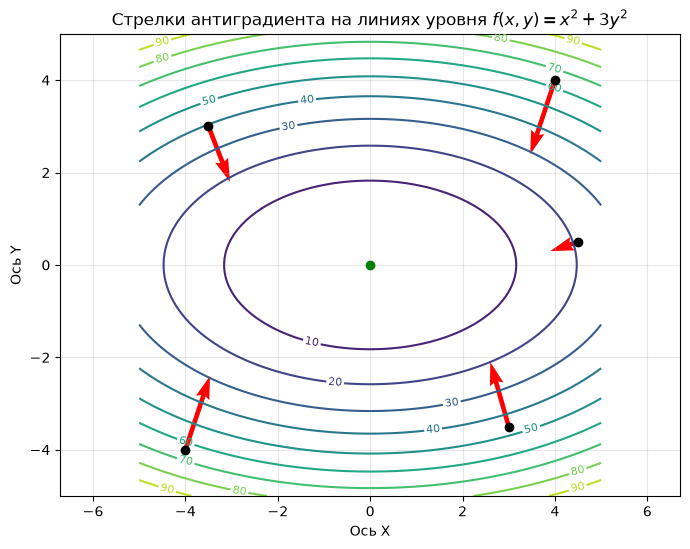

In [8]:
from matplotlib import pyplot as plt 

f = lambda x, y: x ** 2 + 3 * y **2
grad = lambda x, y: (2 * x, 6 * y)
antigrad = lambda x, y: (-2 * x, -6 * y)

x = np.linspace(-5, 5, 100)
y = np.linspace(-5, 5, 100)
X, Y = np.meshgrid(x, y)
Z = f(X, Y)

plt.figure(figsize=(8, 6))

# рисуем линии уровня с помощью contour и подписываем их с помощью clabel
level_lines = plt.contour(X, Y, Z, levels=10)
plt.clabel(level_lines, inline=True, fontsize=8)

points = np.array([
    [4.0, 4.0],    # Первая четверть
    [-3.5, 3.0],   # Вторая четверть
    [-4.0, -4.0],  # Третья четверть
    [3.0, -3.5],   # Четвертая четверть
    [4.5, 0.5]     # Около оси X
])

X_p, Y_p = points[:, 0], points[:, 1]
U, V = antigrad(X_p, Y_p)

# рисуем стрелки градиента с помощью quiver
plt.quiver(X_p, Y_p, U, V, angles='xy', scale_units='xy', scale=15, color='red')

# Отмечаем сами точки и центр минимума
plt.scatter(X_p, Y_p, color='black', zorder=5)
plt.scatter(0, 0, color='green', zorder=5)

plt.title('Стрелки антиградиента на линиях уровня $f(x, y) = x^2 + 3y^2$')
plt.xlabel('Ось X')
plt.ylabel('Ось Y')
plt.grid(alpha=0.3)
plt.axis('equal') # Важно, чтобы эллипсы не искажались масштабом осей
plt.show()

5. **GD на параболе.** Запустите ваш `gradient_descent` с разными `lr`: 0.001, 0.1, 0.5, 1.0. Постройте графики сходимости. Где он расходится?


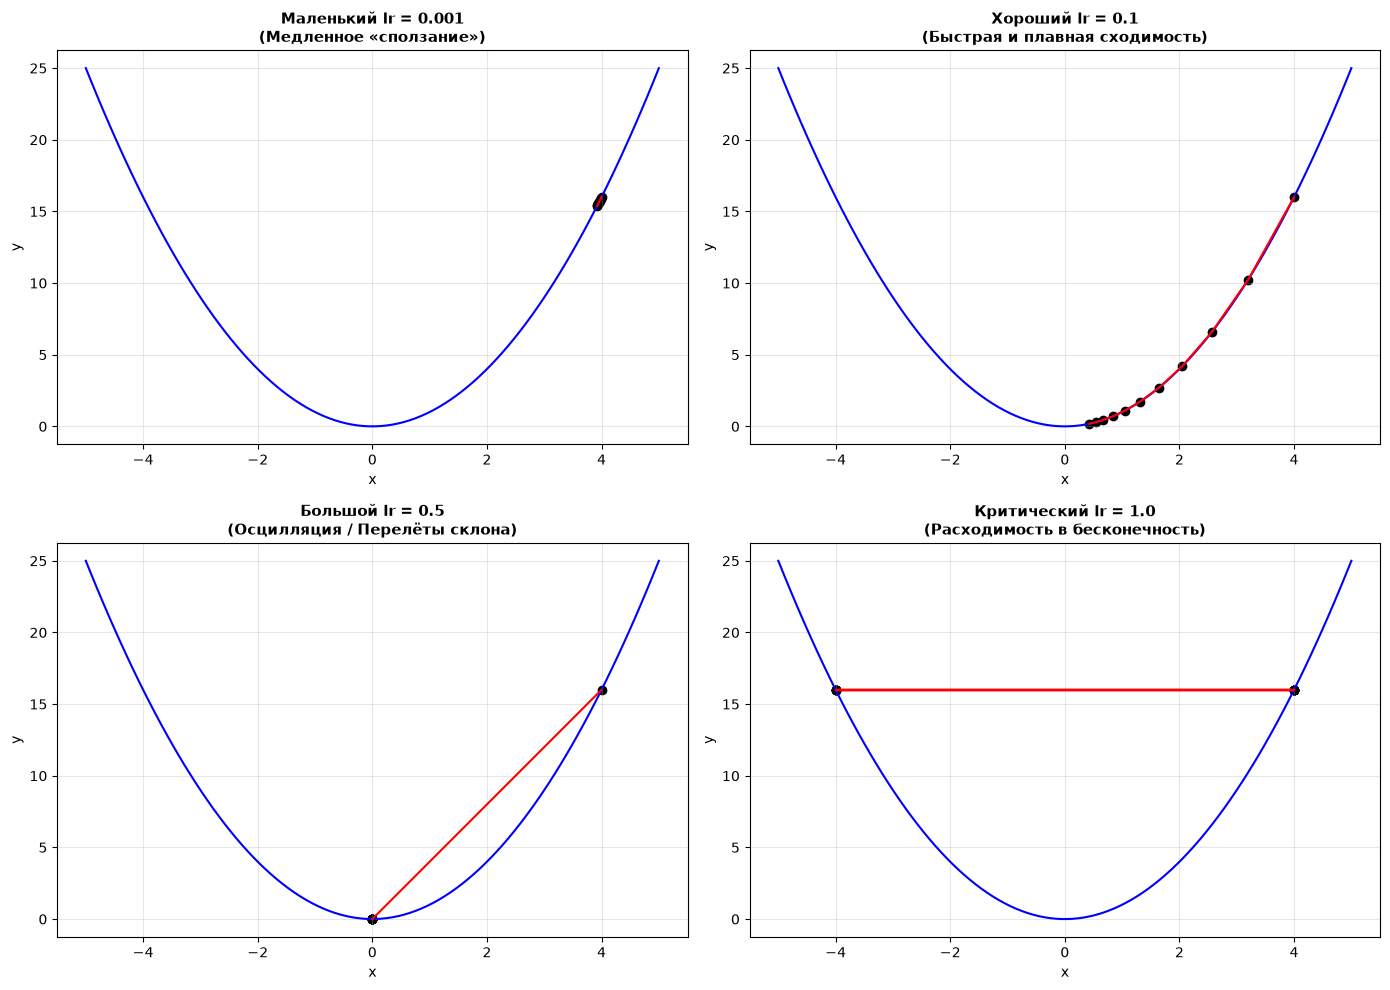

In [9]:
def gradient_descent(f, grad_f, x0, lr=0.1, steps=1000):
    x = float(x0)
    history_x = [x]
    history_y = [f(x)]
    for _ in range(steps):
        x = x - lr * grad_f(x)
        history_x.append(x)
        history_y.append(f(x))

    return x, history_x, history_y


f = lambda x: x ** 2
grad = lambda x: 2 * x
lr_values = [0.001, 0.1, 0.5, 1.0]

titles = [
    "Маленький lr = 0.001\n(Медленное «сползание»)",
    "Хороший lr = 0.1\n(Быстрая и плавная сходимость)",
    "Большой lr = 0.5\n(Осцилляция / Перелёты склона)",
    "Критический lr = 1.0\n(Расходимость в бесконечность)"
]

fig, axes = plt.subplots(2, 2,  figsize=(14, 10))
axes = axes.ravel()

x = np.linspace(-5, 5, 100)
y = f(x)

for i, lr in enumerate(lr_values):
    ax =axes[i]

    x_min, hist_x, hist_y = gradient_descent(f, grad, x0=4.0, lr=lr, steps=10)

    ax.plot(x, y, color="blue")
    ax.plot(hist_x, hist_y, color="red")
    ax.scatter(hist_x, hist_y, color="black")

    ax.set_title(titles[i], fontsize=11, fontweight="bold")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_xlim(-5.5, 5.5)

    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()



6. **Овраг Розенброка.** Запустите GD на функции `f(x, y) = (1-x)² + 100(y - x²)²`. Покажите визуально, как он зигзагит. Сравните с моментом.


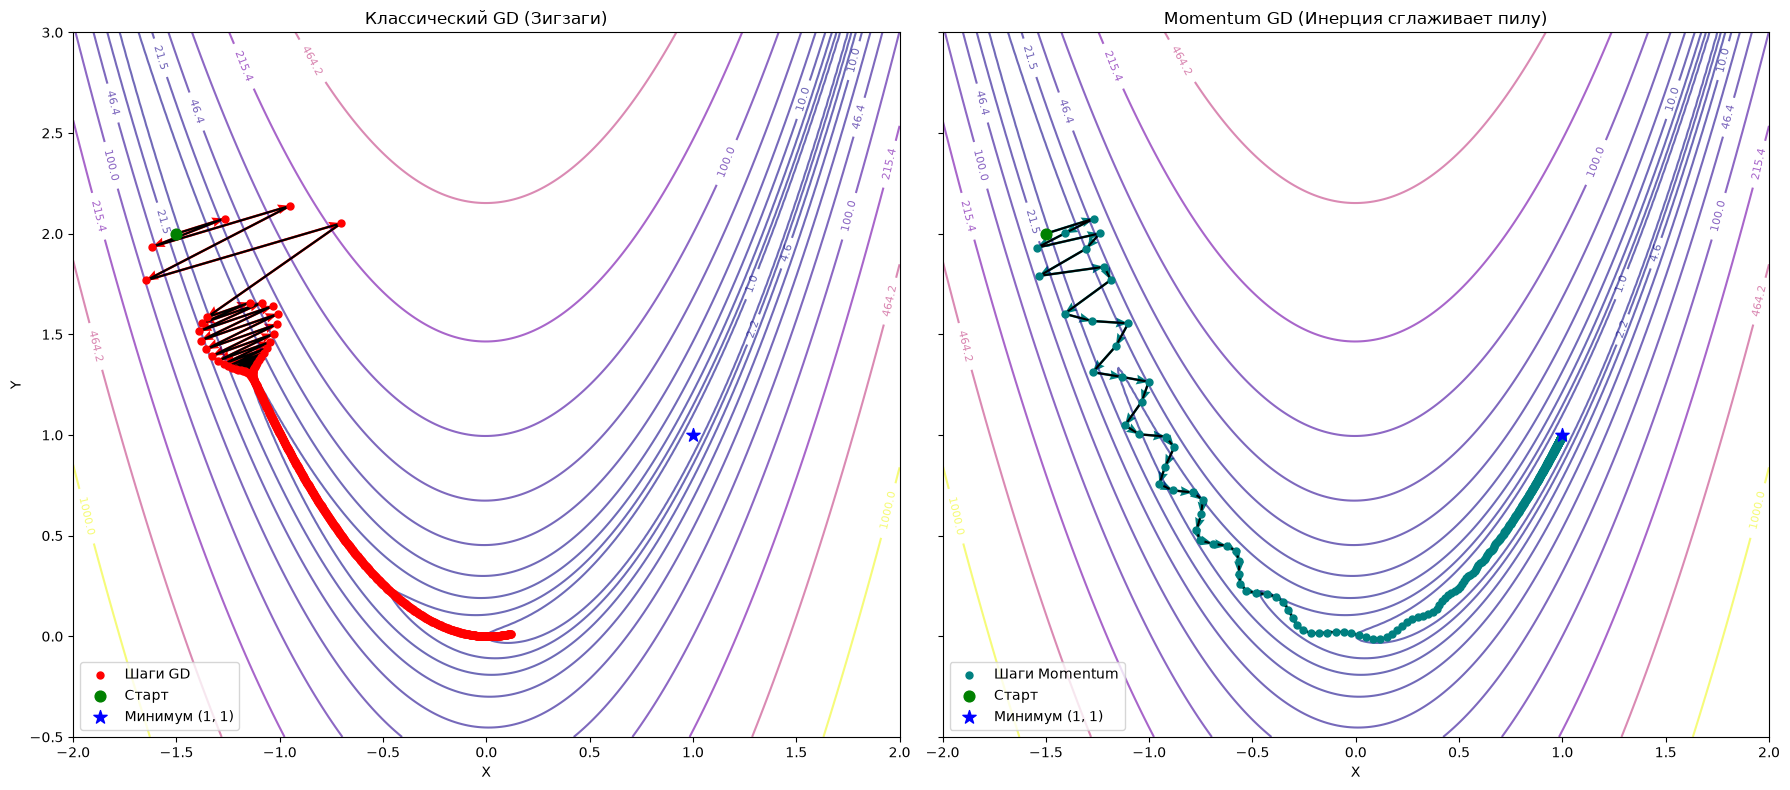

In [10]:
def rosenbrock(x, y):
    return (1 - x)**2 + 100 * (y - x**2)**2

def grad_rosenbrock(x, y):
    df_dx = -2 * (1 - x) - 400 * x * (y - x**2)
    df_dy = 200 * (y - x**2)
    return np.array([df_dx, df_dy])

# --- Исходные параметры ---
start_point = np.array([-1.5, 2.0])
lr = 0.0015
steps = 700

# ==========================================
# 1. Запуск классического GD 
# ==========================================
history = [start_point]
cur_point = start_point.copy()

for _ in range(steps):
    grad = grad_rosenbrock(cur_point[0], cur_point[1])
    cur_point -= lr * grad
    history.append(cur_point.copy())

history = np.array(history)

# ==========================================
# 2. Запуск Momentum GD 
# ==========================================
history_mom = [start_point]
cur_point_mom = start_point.copy()
v = np.zeros(2)  # Начальная скорость (импульс) равна нулю
beta = 0.9       # Коэффициент удержания прошлой скорости (90%)

for _ in range(steps):
    grad_mom = grad_rosenbrock(cur_point_mom[0], cur_point_mom[1])
    # Вычисляем новый импульс и обновляем точку
    v = beta * v + lr * grad_mom
    cur_point_mom -= v
    history_mom.append(cur_point_mom.copy())

history_mom = np.array(history_mom)

# ==========================================
# 3. Визуализация (два графика рядом)
# ==========================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8), sharex=True, sharey=True)

# Сетка для изолиний (общая для обоих графиков)
x = np.linspace(-2.0, 2.0, 250)
y = np.linspace(-0.5, 3.0, 250)
X, Y = np.meshgrid(x, y)
Z = rosenbrock(X, Y)
log_levels_lines = np.logspace(0, 3, 10)

# --- График 1: Классический GD ---
cs1 = ax1.contour(X, Y, Z, levels=log_levels_lines, cmap='plasma', alpha=0.6)
ax1.clabel(cs1, inline=True, fontsize=8)

ax1.plot(history[:, 0], history[:, 1], color="black")
ax1.scatter(history[:, 0], history[:, 1], color="red", s=25, zorder=5, label='Шаги GD')

U, V = np.diff(history[:, 0]), np.diff(history[:, 1])
ax1.quiver(history[:-1, 0], history[:-1, 1], U, V, angles='xy', scale_units='xy', scale=1, 
           color='red', width=0.003, headwidth=4)

ax1.scatter(start_point[0], start_point[1], color='green', marker='o', s=60, label='Старт', zorder=6)
ax1.scatter(1, 1, color='blue', marker='*', s=100, label='Минимум (1, 1)', zorder=6)
ax1.set_title('Классический GD (Зигзаги)')
ax1.set_xlabel('X')
ax1.set_ylabel('Y')
ax1.legend()

# --- График 2: Momentum GD (сглаженный импульс) ---
cs2 = ax2.contour(X, Y, Z, levels=log_levels_lines, cmap='plasma', alpha=0.6)
ax2.clabel(cs2, inline=True, fontsize=8)

ax2.plot(history_mom[:, 0], history_mom[:, 1], color="black")
ax2.scatter(history_mom[:, 0], history_mom[:, 1], color="teal", s=25, zorder=5, label='Шаги Momentum')

U_mom, V_mom = np.diff(history_mom[:, 0]), np.diff(history_mom[:, 1])
ax2.quiver(history_mom[:-1, 0], history_mom[:-1, 1], U_mom, V_mom, angles='xy', scale_units='xy', scale=1, 
           color='teal', width=0.003, headwidth=4)

ax2.scatter(start_point[0], start_point[1], color='green', marker='o', s=60, label='Старт', zorder=6)
ax2.scatter(1, 1, color='blue', marker='*', s=100, label='Минимум (1, 1)', zorder=6)
ax2.set_title('Momentum GD (Инерция сглаживает пилу)')
ax2.set_xlabel('X')
ax2.legend()

plt.tight_layout()
plt.show()


# Оптимизация: Классический градиентный спуск (GD) vs Метод импульса (Momentum)

При поиске экстремумов сложных функций (таких как овраг Розенброка) выбор алгоритма оптимизации критически влияет на скорость и успешность схождения к минимуму.

---

## 1. Классический градиентный спуск (Gradient Descent, GD)

**Идея метода:**  
Алгоритм делает шаг в сторону, противоположную вектору градиента в текущей точке. Он принимает решение «здесь и сейчас», совершенно не учитывая историю предыдущих шагов.

### Математическая формула:
$$x_{t+1} = x_t - \eta \cdot \nabla f(x_t)$$

Где:
* $x_t$ — текущее положение (вектор параметров).
* $\eta$ (learning rate) — шаг обучения.
* $\nabla f(x_t)$ — вектор градиента функции в точке $x_t$.

### Главная проблема (Почему он «зигзагит»):
В узких и вытянутых структурах (оврагах) градиент на крутых боковых стенках в десятки раз больше, чем градиент вдоль пологого дна. 
* Алгоритм видит огромный наклон стенки, делает резкий прыжок **поперек** оврага и перелетает на противоположный склон.
* На следующем шаге ситуация повторяется в обратную сторону.
* Возникают сильные **осцилляции (зигзаги)**. Вся энергия шага уходит на метания между стенками, а продвижение к истинному минимуму вдоль дна практически останавливается.

---

## 2. Градиентный спуск с импульсом (Momentum GD)

**Идея метода:**  
В алгоритм добавляется физическая аналогия **инерции**. Представьте тяжелый металлический шарик, катящийся по желобу. Набрав скорость, он не может мгновенно развернуться на 180 градусов из-за накопленного импульса. Он сглаживает мелкие неровности и летит вперед.

Вектор скорости $v_t$ накапливает в себе направления прошлых шагов, плавно корректируя траекторию.

### Математическая формула:
1. **Вычисление текущей скорости (импульса):**
$$v_t = \beta \cdot v_{t-1} + \eta \cdot \nabla f(x_t)$$

2. **Обновление координат:**
$$x_{t+1} = x_t - v_t$$

Где:
* $v_t$ — вектор скорости на шаге $t$ (изначально равен нулю).
* $\beta$ (momentum) — коэффициент затухания импульса (обычно $\beta = 0.9$). Показывает, какую долю прошлой скорости мы сохраняем.

### Почему Momentum лечит зигзаги:
* **Поперек оврага:** Направление градиента постоянно меняет знак (то влево, то вправо). При суммировании в формуле скорости $v_t$ эти противоположные направления взаимно гасят друг друга. Колебания затухают.
* **Вдоль оврага:** Градиент всегда направлен в одну сторону — к минимуму. Из шага в шаг эти компоненты складываются, и алгоритм **«разгоняется» вдоль дна оврага**, подобно катящемуся снежному кому.

---

## 3. Сравнение поведения на финише

| Критерий | Классический GD | Momentum GD |
| :--- | :--- | :--- |
| **Поведение в овраге** | Бесконечно рикошетит от стенок, тратя тысячи шагов впустую. | Быстро гасит колебания и плавно скользит по дну. |
| **Достижение минимума** | Часто застревает на полпути из-за микроскопического прогресса. | Гарантированно добирается до точного минимума $(1, 1)$. |
| **Особенность на финише** | Тормозит и замирает, не дойдя до цели. | Из-за накопленной инерции **пролетает минимум**, а затем совершает затухающие колебания вокруг него (как маятник), пока не остановится. |


7. **MSE-градиент.** Для `L(w) = (1/n) Σ (y_i - x_i·w)²` выведите градиент по `w` аналитически и численно. Должно совпасть.


In [16]:
np.random.seed(42)
n = 100
X_data = np.random.randn(n)
Y_data = 2.5 * X_data + np.random.randn(n) * 0.1

def mse_loss(w):
    return np.mean((Y_data - X_data * w) ** 2)

def mse_gradient_analytic(w):
    return -2 / n * np.sum(X_data * (Y_data - X_data * w))

def mse_gradient_numerical(w, h=1e-5):
    return (mse_loss(w + h) - mse_loss(w - h)) / (2 * h)

w_test = 0.5

grad_analytic = mse_gradient_analytic(w_test)
grad_numerical = mse_gradient_numerical(w_test)

print(f"Тестируемый вес w: {w_test}")
print(f"Аналитический градиент: {grad_analytic:.12f}")
print(f"Численный градиент:     {grad_numerical:.12f}")
print(f"Абсолютное расхождение: {abs(grad_analytic - grad_numerical):.12e}")

Тестируемый вес w: 0.5
Аналитический градиент: -3.285367394555
Численный градиент:     -3.285367394512
Абсолютное расхождение: 4.333289282954e-11


### Разбор значения градиента: что означают полученные $-3.2$?

Когда алгоритм вычисляет градиент функции потерь (ошибки) и выдает конкретное число (в данном случае **$-3.2$**), он отвечает на два главных вопроса: **в какую сторону крутить вес $w$** и **насколько сильно этот вес сейчас влияет на ошибку**.

---

#### 1. Знак «минус» (Куда двигаться)

По определению, **сам вектор градиента всегда указывает направление наискорейшего роста функции (ошибки)**. 
* Раз градиент получился отрицательным ($-3.2$), это означает, что при *увеличении* веса $w$ функция ошибки идет вниз — то есть **уменьшается**. Направление крутого подъема ведет налево, а нам нужно спускаться — значит, нужно идти направо (увеличивать $w$).
* Направление спуска — это **антиградиент**. Для значения $-3.2$ противоположным будет $+3.2$. Знак «плюс» сообщает алгоритму: *«Прибавь значение к весу $w$, увеличивай его!»*

**Посмотрим, как это работает внутри формулы шага:**
$$ w_{\text{new}} = w_{\text{old}} - \text{lr} \cdot \nabla L(w) $$

Подставим текущие числа (допустим, текущий вес $w = 0.5$, а скорость обучения $\text{lr} = 0.1$):
$$ w_{\text{new}} = 0.5 - 0.1 \cdot (-3.2) $$
Минус на минус дает плюс, и параметры обновляются в нужную сторону:
$$ w_{\text{new}} = 0.5 + 0.32 = 0.82 $$
Формула автоматически **увеличила** вес с $0.5$ до $0.82$, продвинув модель ближе к истинному значению (в нашем тесте это $2.5$).

---

#### 2. Модуль числа $3.2$ (С какой скоростью падать)

Абсолютное значение градиента — это **коэффициент чувствительности** ошибки к изменению веса в данной точке (мгновенная скорость изменения).

* Если прямо сейчас увеличить вес $w$ на крошечную величину (например, на $\Delta w = +0.01$), то ошибка модели (MSE) уменьшится примерно в $3.2$ раза сильнее, то есть просядет на $0.01 \cdot 3.2 = 0.032$.
* Величина числа показывает, **насколько сильно модель сейчас промахивается**. Поскольку текущий вес равен $0.5$, а оптимум находится в районе $2.5$, модель ошибается довольно сильно. Склон горы в этой точке крутой, поэтому и скорость изменения высокая ($3.2$).

---

#### 3. Динамика градиента в процессе обучения

Градиент не остается постоянным. Если запустить градиентный спуск циклически, значение будет меняться следующим образом:

1. **Старт ($w = 0.5$):** Мы очень далеко от цели. Градиент равен **$-3.2$** (Склон крутой, быстро увеличиваем вес).
2. **Середина ($w = 1.5$):** Мы подобрались ближе. Градиент станет равен примерно **$-1.5$** (Ошибок меньше, склон более пологий, шаги автоматически уменьшаются).
3. **Почти у цели ($w = 2.4$):** Мы практически угадали. Градиент равен, например, **$-0.1$** (Модель делает микроскопические осторожные шажки).
4. **Минимум ($w = 2.5$):** Ошибка минимальна. Градиент становится равен **$0.0$**. Формула спуска превращается в $w = w - \text{lr} \cdot 0$. Вес замирает, обучение успешно завершено.

> 💡 **А если бы градиент был положительным (например, $+4.0$)?**  
> Это означало бы, что мы переборщили с весом и ушли слишком далеко вправо (например, выставили $w = 5.0$). Плюс показал бы, что при дальнейшем увеличении веса ошибка растет. Формула спуска из-за знака минус автоматически начала бы **вычитать** значение: $w_{\text{new}} = 5.0 - 0.1 \cdot (+4.0) = 4.6$, возвращая модель назад к идеалу.


---
---
### Как понимать знак градиента: подробный логический переход

Чтобы окончательно разобраться, как знак «минус» управляет движением алгоритма, разберем логическую связь между двумя утверждениями:
1. *«Градиент всегда показывает направление наискорейшего роста ошибки».*
2. *«Раз градиент равен $-3.2$, то при увеличении веса $w$ ошибка уменьшается».*

---

#### Шаг 1. Как математика определяет знак производной (градиента)

В математическом анализе знак любой производной всегда привязан к движению **слева направо** (то есть в сторону **увеличения** аргумента $w$):
* **Знак ПЛЮС ($+$):** означает, что если мы увеличиваем $w$ (идем вправо), функция ошибки **растет**.
* **Знак МИНУС ($-$):** означает, что если мы увеличиваем $w$ (идем вправо), функция ошибки **падает (уменьшается)**.

---

#### Шаг 2. Как знак «минус» разворачивает стрелку градиента

На обычной числовой оси направление «плюс» — это движение вправо, а «минус» — это движение влево.

Когда вычисляется градиент, он ищет путь наискорейшего **роста**. 
* Если бы градиент был равен $+3.2$, стрелка роста указывала бы направо (в плюс).
* Но наш градиент равен **$-3.2$**. Знак «минус» перед числом буквально разворачивает стрелку роста в противоположную сторону — **налево** (в сторону уменьшения веса $w$).

---

#### Шаг 3. Финальная логическая цепочка

Соединяем всё вместе:
1. Из вычислений мы узнали, что градиент равен **$-3.2$**.
2. Из фундаментального свойства градиента мы знаем, что он указывает туда, где ошибка **растет**.
3. Значит, направление **роста ошибки — это НАЛЕВО** (в сторону уменьшения веса $w$).
4. Следовательно, в противоположную сторону — **НАПРАВО** (в сторону **увеличения** веса $w$) — ошибка будет делать противоположное действие, то есть **УМЕНЬШАТЬСЯ**.

Именно так из первого утверждения строго следует второе. Получив значение $-3.2$, алгоритм мгновенно понимает: *«Раз ошибка растет при движении налево, значит, мне нужно идти направо (увеличивать вес $w$), чтобы ошибка уменьшалась»*.

---

#### Как это работает в формуле шага

Чтобы пойти направо (в сторону уменьшения ошибки), алгоритм использует знак «минус» перед скоростью обучения $\text{lr}$:
$$ w_{\text{new}} = w_{\text{old}} - \text{lr} \cdot \nabla L(w) $$

Подставляя наш отрицательный градиент ($-3.2$), мы сталкиваемся с правилом «минус на минус дает плюс»:
$$ w_{\text{new}} = w_{\text{old}} - \text{lr} \cdot (-3.2) = w_{\text{old}} + \text{lr} \cdot 3.2 $$

Математика сама превратила вычитание в **сложение**, заставив алгоритм увеличить вес $w$ и пойти направо, к заветному минимуму.


---
8. **Своя линейная регрессия GD.** Обучите w на 100 точках с шумом, используя только ваш градиентный спуск. Сравните с `np.linalg.solve(X.T @ X, X.T @ y)`.


In [31]:
def mse_loss(w, X, y):
    return np.mean((y - X * w) ** 2)

def mse_gradient_analytic(w, X, y):
    return -2 / n * np.sum(X * (y - X * w))

def gradient_descent(f, grad_f, w0, lr=0.1, steps=1000):
    w = float(w0)
    history = [w]

    for _ in range(steps):
        w = w - lr * grad_f(w, X, y)
        history.append(w)

    return w, np.array(history)

np.random.seed(42)
n = 100
X = np.random.randn(n)
w_true = 2.5
y = w_true * X + np.random.randn(n) * 0.1

w0 = 0.0
w_grad, hist = gradient_descent(mse_loss, mse_gradient_analytic,
                           w0=w0, lr=0.1, steps=100)


# В reshape можно передать число -1 для одного из измерений. 
# Это означает: "NumPy, посчитай размер этой оси автоматически, "
# "исходя из оставшегося количества элементов".

# В машинном обучении градиентный спуск часто ожидает признаки 
# в виде вектора-столбца. Конвертация features.reshape(-1, 1) — 
# стандартный шаг подготовки данных.
X_mat = X.reshape(-1, 1)
y_mat = y.reshape(-1, 1)

w_np = np.linalg.solve(X_mat.T @ X_mat, X_mat.T @ y_mat)

print(f"Истинный «секретный» вес (w_true) = {w_true}")
print(f"Вес, найденный вашим GD (w_gd) = {w_grad}")
print(f"Вес, найденный через solve (МНК) = {w_np[0, 0]}")
print(f"Абсолютное расхождение решений = {abs(w_grad - w_np[0, 0])}")




Истинный «секретный» вес (w_true) = 2.5
Вес, найденный вашим GD (w_gd) = 2.4855810124507958
Вес, найденный через solve (МНК) = 2.485581047130723
Абсолютное расхождение решений = 3.467992737427039e-08


# Итоговый чек-лист по производным и градиентному спуску

---

## 1.Производные базовых функций

### Полином (степенная функция)
$$\frac{d}{dx}(x^n) = n \cdot x^{n-1}$$

*При наличии константы она просто выносится:*
$$\frac{d}{dx}(c \cdot x^n) = c \cdot n \cdot x^{n-1}$$

**Пример:**
$$\frac{d}{dx}(5x^4) = 20x^3$$

---

### Экспонента
$$\frac{d}{dx}(e^x) = e^x$$

*Если в основании другое число:*
$$\frac{d}{dx}(a^x) = a^x \cdot \ln a$$

**Примеры:**
$$\frac{d}{dx}(e^{2x}) = 2e^{2x} \quad \text{(цепное правило)}$$
$$\frac{d}{dx}(3^x) = 3^x \cdot \ln 3$$

---

### Логарифм (натуральный)
$$\frac{d}{dx}(\ln x) = \frac{1}{x}$$

*Если логарифм по другому основанию:*
$$\frac{d}{dx}(\log_a x) = \frac{1}{x \cdot \ln a}$$

**Примеры:**
$$\frac{d}{dx}(\ln(5x)) = \frac{1}{x}$$
$$\frac{d}{dx}(\log_2 x) = \frac{1}{x \cdot \ln 2}$$

---

## 2.Производные функций активации

### Сигмоида (Sigmoid)
$$\sigma(x) = \frac{1}{1 + e^{-x}}$$

$$\sigma'(x) = \sigma(x) \cdot (1 - \sigma(x))$$

*Особенность:* производная идеально выражается через саму функцию, что крайне удобно для вычислений в нейросетях (бэкпропагейшн).

**Максимальное значение:** $\sigma'(0) = 0.25$

---

### Гиперболический тангенс (tanh)
$$\tanh(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}}$$

$$\tanh'(x) = 1 - \tanh^2(x)$$

**Максимальное значение:** $\tanh'(0) = 1$

---

### ReLU (Rectified Linear Unit)
$$\text{ReLU}(x) = \max(0, x)$$

$$\text{ReLU}'(x) = \begin{cases} 1, & \text{если } x > 0 \\ 0, & \text{если } x < 0 \end{cases}$$

> В точке $x = 0$ производная математически не определена. На практике в коде её жестко принимают за $0$ или $0.5$ (субградиент).

---

## 3.Почему градиент указывает в сторону наискорейшего роста?

Градиент — это вектор, состоящий из частных производных по каждой переменной:

$$\nabla f(x_1, x_2, ..., x_n) = \begin{bmatrix} \frac{\partial f}{\partial x_1} \\ \frac{\partial f}{\partial x_2} \\ \vdots \\ \frac{\partial f}{\partial x_n} \end{bmatrix}$$

В математическом анализе знак любой производной строго привязан к движению **слева направо** (к увеличению аргумента):

- Если при увеличении параметра функция идёт вверх, производная будет **положительной** $(+)$. Компонент вектора направлен вправо (в сторону роста).
- Если при увеличении параметра функция падает, производная будет **отрицательной** $(-)$. Компонент вектора развернётся влево (туда, где значения функции были выше).

**Геометрическая интуиция:**
$$\nabla f = \begin{bmatrix} \frac{\partial f}{\partial x} \\ \frac{\partial f}{\partial y} \end{bmatrix} = \text{направление наискорейшего подъёма}$$

> Представьте, что вы стоите на холме в тумане. Градиент показывает направление самого крутого подъёма. Чтобы спуститься, идите **противоположно** градиенту $(-\nabla f)$.

---

## 4.Минималистичная реализация градиентного спуска

Компактная и полностью рабочая функция градиентного спуска на Python / NumPy:

```python
def gradient_descent(grad_f, x0, lr=0.1, steps=100):
    # 1. Инициализация (делаем копию, чтобы избежать изменения по ссылке)
    x = x0.copy() if hasattr(x0, 'copy') else float(x0) 
    
    # 2. Итерационный цикл оптимизации
    for _ in range(steps):
        grad = grad_f(x)          # 3. Расчёт градиента в текущей точке
        x = x - lr * grad         # 4. Шаг против градиента (к минимуму)
        
    return x                      # 5. Возврат найденных оптимальных параметров
```

## 5.Суть обучения модели как поиска минимума

Обучение абсолютно любой модели машинного обучения (от простейшей линейной регрессии до сложных языковых моделей) — это **задача математической минимизации функции потерь**.

### Функция потерь (Loss function)
Выполняет роль «калькулятора штрафов». Она берёт текущие предсказания модели, сравнивает их с реальными правильными ответами и выдаёт итоговое число — величину ошибки:

$$\mathcal{L}(\theta) = \frac{1}{N} \sum_{i=1}^{N} \text{loss}(y_i, \hat{y}_i)$$

Где:
- $\theta$ — параметры модели
- $y_i$ — истинные значения
- $\hat{y}_i$ — предсказания модели
- $N$ — количество примеров

### Процесс обучения
Градиентный спуск выступает в роли навигатора. Он смотрит на ландшафт функции потерь и шаг за шагом подкручивает внутренние параметры (веса) модели так, чтобы спуститься на самое дно многомерной «впадины»:

$$\theta_{t+1} = \theta_t - \eta \cdot \nabla_{\theta} \mathcal{L}(\theta_t)$$

Где штрафной балл за ошибки будет минимальным (стремится к нулю).

### Пример: линейная регрессия

**Модель:** 
$$\hat{y} = w \cdot x + b$$

**Функция потерь (MSE):**
$$\mathcal{L}(w, b) = \frac{1}{N} \sum_{i=1}^{N} (y_i - (w \cdot x_i + b))^2$$

**Градиенты:**
$$\frac{\partial \mathcal{L}}{\partial w} = \frac{2}{N} \sum_{i=1}^{N} (y_i - \hat{y}_i) \cdot (-x_i)$$

$$\frac{\partial \mathcal{L}}{\partial b} = \frac{2}{N} \sum_{i=1}^{N} (y_i - \hat{y}_i) \cdot (-1)$$

**Обновление параметров:**
$$w_{t+1} = w_t - \eta \cdot \frac{\partial \mathcal{L}}{\partial w}$$

$$b_{t+1} = b_t - \eta \cdot \frac{\partial \mathcal{L}}{\partial b}$$